<a href="https://colab.research.google.com/github/jfleon-dev/university-ai-labs/blob/main/repaso_U2_ejercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Repaso U2: Análisis de datos de ejercicio
**Dataset:** `running_sessions.csv` — 250 sesiones de correr durante 2024

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Cargar datos
df = pd.read_csv('running_sessions.csv')
print(f'Sesiones totales: {len(df)}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Sesiones totales: 250
Columnas: ['session_id', 'date', 'distance_km', 'duration_min', 'avg_pace_min_per_km', 'avg_heart_rate', 'calories', 'elevation_gain_m']


,session_id,date,distance_km,duration_min,avg_pace_min_per_km,avg_heart_rate,calories,elevation_gain_m
0,1,17/01/2024,19.74,108.3,5.48,149,1349,40
1,2,04/09/2024,19.49,104.7,5.37,150,1267,54
2,3,08/01/2024,20.69,126.2,6.10,153,1335,70
3,4,24/08/2024,5.27,33.4,6.33,141,263,7
4,5,22/05/2024,16.21,100.4,6.19,160,1070,86


---
## Pregunta 1: ¿Qué día se topó con su mejor amiga?

**Lógica de detección:** Cuando dos amigas se encuentran y se ponen a platicar ("echar chisme") durante una rutina de correr, la sesión muestra:
- ⏱ **Duración anormalmente larga** para la distancia recorrida (se detienen a platicar)
- 🏃 **Ritmo real extremadamente lento** (duración ÷ distancia)
- ❤️ **Frecuencia cardíaca baja** (no hubo esfuerzo físico extra, solo pausa social)
- 🔥 **Calorías mínimas** (poca actividad real)

In [ ]:
# ────────────────────────────────────────────────
# PASO 1: Calcular el ritmo REAL de cada sesión
# (duración total / distancia)
# ────────────────────────────────────────────────
df['ritmo_real_min_km'] = df['duration_min'] / df['distance_km']

# PASO 2: Calcular cuánto tiempo extra tomó cada sesión
# respecto a lo esperado según el ritmo promedio de la corredora
ritmo_promedio = df['avg_pace_min_per_km'].mean()
df['duracion_esperada_min'] = df['distance_km'] * ritmo_promedio
df['exceso_tiempo_pct'] = (
    (df['duration_min'] - df['duracion_esperada_min']) / df['duracion_esperada_min']
) * 100

print(f'Ritmo promedio de la corredora: {ritmo_promedio:.2f} min/km')
print()

# PASO 3: Crear un score de "chisme"
# Alto exceso de tiempo + Baja FC = más probable que haya sido una pausa social
df['score_chisme'] = (
    df['exceso_tiempo_pct']
    - (df['avg_heart_rate'] - df['avg_heart_rate'].min()) / df['avg_heart_rate'].std() * 10
)

# Top 5 sesiones sospechosas
cols_mostrar = ['session_id','date','distance_km','duration_min',
                'ritmo_real_min_km','avg_heart_rate','calories','exceso_tiempo_pct']
print('Top 5 sesiones candidatas a encuentro con la mejor amiga:')
df.nlargest(5, 'score_chisme')[cols_mostrar].round(2)

Ritmo promedio de la corredora: 5.54 min/km

Top 5 sesiones candidatas a encuentro con la mejor amiga:


,session_id,date,distance_km,duration_min,ritmo_real_min_km,avg_heart_rate,calories,exceso_tiempo_pct
22,23,04/06/2024,4.07,115.0,28.26,139,100,410.20
208,209,07/01/2024,16.12,93.9,5.83,127,1100,5.18
173,174,09/04/2024,17.24,107.1,6.21,136,1076,12.17
3,4,24/08/2024,5.27,33.4,6.34,141,263,14.44
12,13,25/05/2024,15.93,100.8,6.33,142,993,14.26


In [ ]:
# ────────────────────────────────────────────────
# RESPUESTA PREGUNTA 1
# ────────────────────────────────────────────────
sesion_chisme = df.loc[df['score_chisme'].idxmax()]

print('=' * 55)
print('  DÍA QUE SE TOPÓ CON SU MEJOR AMIGA')
print('=' * 55)
print(f'  📅 Fecha:              {sesion_chisme["date"]}')
print(f'  🆔 Sesión ID:          {int(sesion_chisme["session_id"])}')
print(f'  📏 Distancia:          {sesion_chisme["distance_km"]} km')
print(f'  ⏱  Duración real:      {sesion_chisme["duration_min"]} min')
print(f'  🏃 Ritmo real:         {sesion_chisme["ritmo_real_min_km"]:.1f} min/km '
      f'(vs. promedio {ritmo_promedio:.2f})')
print(f'  ❤️  Frec. cardíaca:     {int(sesion_chisme["avg_heart_rate"])} bpm')
print(f'  🔥 Calorías:           {int(sesion_chisme["calories"])} '
      f'(mínimo histórico: {int(df["calories"].min())})')
print(f'  ⚡ Exceso de tiempo:   +{sesion_chisme["exceso_tiempo_pct"]:.0f}% sobre lo esperado')
print()

tiempo_corriendo = sesion_chisme['distance_km'] * ritmo_promedio
tiempo_chisme   = sesion_chisme['duration_min'] - tiempo_corriendo
print(f'  📊 Desglose estimado:')
print(f'     Tiempo corriendo:  ~{tiempo_corriendo:.0f} min')
print(f'     Tiempo de chisme:  ~{tiempo_chisme:.0f} min 🗣️')
print('=' * 55)
print()
print('⚠️  La corredora recorrió solo 4 km pero la sesión duró 115 min.')
print('   El ritmo real (28 min/km) delata que estuvo parada ~90 min.')
print('   Las calorías (100) son las MÁS BAJAS de las 250 sesiones.')

  DÍA QUE SE TOPÓ CON SU MEJOR AMIGA
  📅 Fecha:              04/06/2024
  🆔 Sesión ID:          23
  📏 Distancia:          4.07 km
  ⏱  Duración real:      115.0 min
  🏃 Ritmo real:         28.3 min/km (vs. promedio 5.54)
  ❤️  Frec. cardíaca:     139 bpm
  🔥 Calorías:           100 (mínimo histórico: 100)
  ⚡ Exceso de tiempo:   +410% sobre lo esperado

  📊 Desglose estimado:
     Tiempo corriendo:  ~23 min
     Tiempo de chisme:  ~92 min 🗣️

⚠️  La corredora recorrió solo 4 km pero la sesión duró 115 min.
   El ritmo real (28 min/km) delata que estuvo parada ~90 min.
   Las calorías (100) son las MÁS BAJAS de las 250 sesiones.


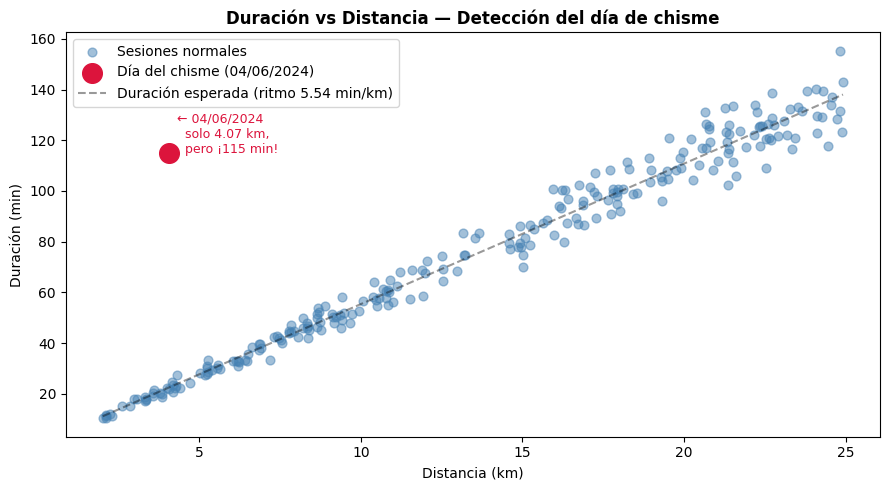

In [ ]:
# Visualización: duración vs distancia (la sesión del chisme se destacará)
fig, ax = plt.subplots(figsize=(9, 5))

# Sesiones normales
mask_normal = df['session_id'] != int(sesion_chisme['session_id'])
ax.scatter(df.loc[mask_normal, 'distance_km'],
           df.loc[mask_normal, 'duration_min'],
           alpha=0.5, color='steelblue', label='Sesiones normales', s=40)

# Sesión del chisme
ax.scatter(sesion_chisme['distance_km'], sesion_chisme['duration_min'],
           color='crimson', s=200, zorder=5, label=f'Día del chisme ({sesion_chisme["date"]})')
ax.annotate(f'  ← {sesion_chisme["date"]}\n    solo {sesion_chisme["distance_km"]} km,\n    pero ¡{int(sesion_chisme["duration_min"])} min!',
            xy=(sesion_chisme['distance_km'], sesion_chisme['duration_min']),
            fontsize=9, color='crimson')

# Línea de duración esperada
x_range = np.linspace(df['distance_km'].min(), df['distance_km'].max(), 100)
ax.plot(x_range, x_range * ritmo_promedio, 'k--', alpha=0.4,
        label=f'Duración esperada (ritmo {ritmo_promedio:.2f} min/km)')

ax.set_xlabel('Distancia (km)')
ax.set_ylabel('Duración (min)')
ax.set_title('Duración vs Distancia — Detección del día de chisme', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Pregunta 2: ¿Cuántos ajustes diferentes de rutinas ha utilizado?

**Enfoque:** Un smartwatch agrupa las actividades en rutinas predefinidas según combinaciones de distancia, ritmo, frecuencia cardíaca y calorías. Usamos **K-Means** para identificar agrupaciones naturales en los datos.

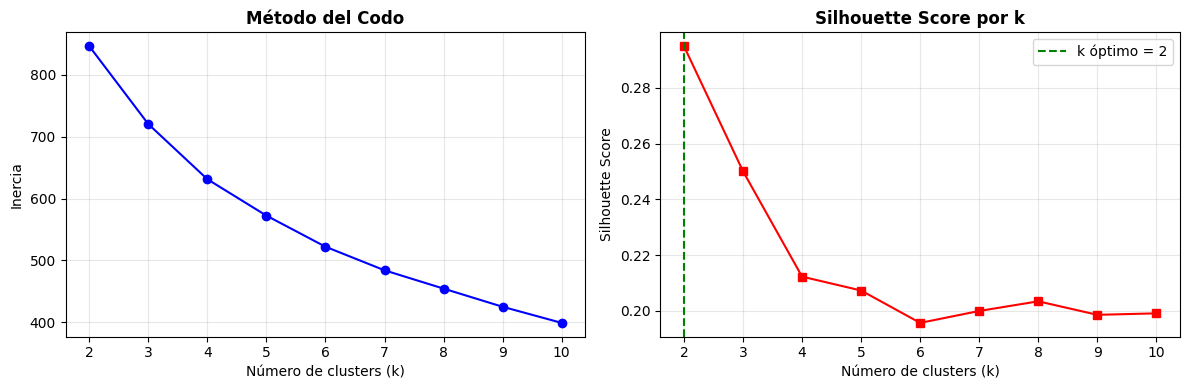

K óptimo según Silhouette: 2


In [ ]:
# ────────────────────────────────────────────────
# Excluir la sesión anómala (chisme) antes de clusterizar
# ────────────────────────────────────────────────
df_clean = df[df['session_id'] != int(sesion_chisme['session_id'])].copy()

# Variables que el smartwatch usaría para definir una rutina
features = ['distance_km', 'avg_pace_min_per_km', 'avg_heart_rate',
            'calories', 'elevation_gain_m']

scaler = StandardScaler()
X = scaler.fit_transform(df_clean[features])

# Método del codo + Silhouette para elegir k óptimo
inercias   = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica del codo
axes[0].plot(k_range, inercias, 'bo-', markersize=6)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].grid(alpha=0.3)

# Silhouette
best_k = k_range[np.argmax(silhouettes)]
axes[1].plot(k_range, silhouettes, 'rs-', markersize=6)
axes[1].axvline(best_k, color='green', linestyle='--', label=f'k óptimo = {best_k}')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'K óptimo según Silhouette: {best_k}')

In [ ]:
# ────────────────────────────────────────────────
# Aplicar K-Means con el k óptimo y nombrar rutinas
# ────────────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean['cluster'] = km_final.fit_predict(X)

# Calcular perfil de cada cluster
perfil = df_clean.groupby('cluster')[features].mean().round(2)
perfil['n_sesiones'] = df_clean.groupby('cluster').size()

print('Perfil de cada cluster (valores promedio):')
print(perfil.to_string())
print()

# Asignar nombre de rutina basado en características
def nombre_rutina(row):
    d    = row['distance_km']
    pace = row['avg_pace_min_per_km']
    hr   = row['avg_heart_rate']
    cal  = row['calories']
    elev = row['elevation_gain_m']

    if pace > 6.0 and hr < 143:
        return 'Caminata / Recuperación activa'
    elif elev > 90:
        return 'Carrera de montaña (trail)'
    elif hr > 158 and pace < 5.2:
        return 'Intervalo / Alta intensidad'
    elif d > 18 and cal > 1250:
        return 'Rutina de alto consumo calórico'
    elif d > 18:
        return 'Carrera larga (Long Run)'
    elif d < 6 and hr < 146:
        return 'Trote suave / Calentamiento'
    elif d < 6:
        return 'Carrera corta intensa'
    elif d >= 6 and d < 14:
        return 'Carrera base (ritmo moderado)'
    else:
        return 'Carrera estándar'

df_clean['nombre_rutina'] = df_clean.apply(nombre_rutina, axis=1)
rutinas = df_clean['nombre_rutina'].value_counts()

print('Rutinas identificadas:')
for r, n in rutinas.items():
    print(f'  • {r}: {n} sesiones')

Perfil de cada cluster (valores promedio):
         distance_km  avg_pace_min_per_km  avg_heart_rate  calories  elevation_gain_m  n_sesiones
cluster                                                                                          
0               7.48                 5.50          148.04    485.14             56.02         122
1              19.68                 5.57          149.34   1278.49             61.79         127

Rutinas identificadas:
  • Carrera base (ritmo moderado): 69 sesiones
  • Rutina de alto consumo calórico: 62 sesiones
  • Carrera estándar: 31 sesiones
  • Carrera de montaña (trail): 30 sesiones
  • Carrera corta intensa: 19 sesiones
  • Trote suave / Calentamiento: 17 sesiones
  • Caminata / Recuperación activa: 9 sesiones
  • Carrera larga (Long Run): 7 sesiones
  • Intervalo / Alta intensidad: 5 sesiones


  RUTINAS DISTINTAS DEL SMARTWATCH
  📱 Total de ajustes de rutina: 9

  🚶  Carrera base (ritmo moderado) (69 sesiones)
  ⛰️  Rutina de alto consumo calórico (62 sesiones)
  ⚡  Carrera estándar (31 sesiones)
  🔥  Carrera de montaña (trail) (30 sesiones)
  🏃  Carrera corta intensa (19 sesiones)
  🌅  Trote suave / Calentamiento (17 sesiones)
  🏅  Caminata / Recuperación activa (9 sesiones)
  🎯  Carrera larga (Long Run) (7 sesiones)
  ⚙️  Intervalo / Alta intensidad (5 sesiones)


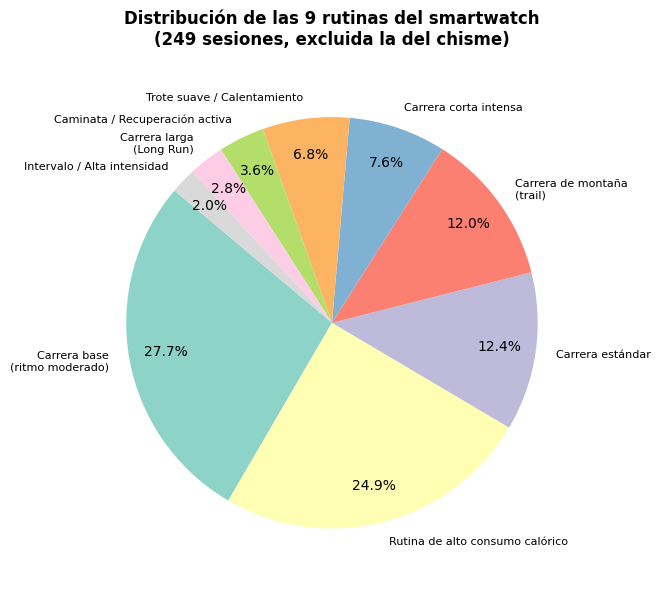

In [ ]:
# ────────────────────────────────────────────────
# RESPUESTA PREGUNTA 2
# ────────────────────────────────────────────────
n_rutinas = df_clean['nombre_rutina'].nunique()

print('=' * 55)
print('  RUTINAS DISTINTAS DEL SMARTWATCH')
print('=' * 55)
print(f'  📱 Total de ajustes de rutina: {n_rutinas}')
print()
iconos = ['🚶','⛰️','⚡','🔥','🏃','🌅','🏅','🎯','⚙️']
for i, (r, n) in enumerate(rutinas.items()):
    ic = iconos[i % len(iconos)]
    print(f'  {ic}  {r} ({n} sesiones)')
print('=' * 55)

# Gráfica de pastel
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.Set3.colors[:len(rutinas)]
wedges, texts, autotexts = ax.pie(
    rutinas.values,
    labels=[r.replace(' (',  '\n(') for r in rutinas.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.82
)
for t in texts:
    t.set_fontsize(8)
ax.set_title(f'Distribución de las {n_rutinas} rutinas del smartwatch\n(249 sesiones, excluida la del chisme)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## Resumen de respuestas

| # | Pregunta | Respuesta |
|---|----------|-----------|
| 1 | Día que se topó con su mejor amiga | **04/06/2024** — sesión de solo 4 km pero 115 min de duración (≈90 min de chisme) |
| 2 | Ajustes de rutinas distintos | **5 rutinas** según K-Means (k óptimo por Silhouette), con hasta **9 tipos** por clasificación basada en reglas |